# Lab 4: Visualizing Geographic Data Distributions in the United States
**Author:** Vandan Amin
### Objective
In this lab, we will:
- Create a map of the United States.
- Show the distribution of geographic data.
- Find five different statistics from the 2020 County Subdivision dataset.
- Make graphs and explain the results in a simple, clear way.



In [117]:
# Import libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# plotting inside the notebook
%matplotlib inline

## Loading the 2020 U.S. County Subdivision Shapefile
We use GeoPandas to load the provided shapefile `cb_2020_us_cousub_500k`. 
This file shows all the smaller areas inside each state, like cities, towns, and townships. 
We will filter it to only the 48 contiguous states (excluding Alaska, Hawaii, and territories).


In [120]:
# Load the shapefile
gdf = gpd.read_file('cb_2020_us_cousub_500k.shp')

# Check the first few rows
gdf.head()

,STATEFP,COUNTYFP,COUSUBFP,COUSUBNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,29,195,22096,00767361,0600000US2919522096,2919522096,Elmwood,Elmwood township,MO,Saline County,Missouri,44,181233131,377337,"POLYGON ((-93.48978 39.06658, -93.48938 39.073..."
1,38,099,45260,01036531,0600000US3809945260,3809945260,Latona,Latona township,ND,Walsh County,North Dakota,44,90848624,2941846,"POLYGON ((-98.16255 48.36954, -98.05746 48.369..."
2,38,017,16100,01036391,0600000US3801716100,3801716100,Cornell,Cornell township,ND,Cass County,North Dakota,44,93440087,0,"POLYGON ((-97.70538 47.04981, -97.70558 47.051..."
3,38,093,22940,01036472,0600000US3809322940,3809322940,Eldridge,Eldridge township,ND,Stutsman County,North Dakota,44,90001176,2572532,"POLYGON ((-98.94567 46.97918, -98.85914 46.979..."
4,38,079,67780,01036243,0600000US3807967780,3807967780,Rolette,Rolette city,ND,Rolette County,North Dakota,25,2609731,0,"POLYGON ((-99.85266 48.6682, -99.83068 48.6681..."


## Filter the 48 Contiguous States

We will remove Alaska, Hawaii, and U.S. territories.  
We only want the main 48 states on the map.



In [123]:
# States and areas to leave out
exclude_states = ['AK', 'HI', 'PR', 'GU', 'VI', 'MP', 'AS', 'DC']

# Keep only the main 48 states
gdf_contiguous = gdf[~gdf['STUSPS'].isin(exclude_states)]

# Double check which states are left
gdf_contiguous['STUSPS'].unique()


array(['MO', 'ND', 'OH', 'MI', 'NH', 'NJ', 'IL', 'MN', 'CO', 'GA', 'NY',
       'WI', 'AR', 'FL', 'SC', 'NE', 'PA', 'MA', 'UT', 'AL', 'OR', 'OK',
       'CA', 'NC', 'TN', 'TX', 'KY', 'AZ', 'ME', 'ID', 'KS', 'IA', 'IN',
       'SD', 'LA', 'MT', 'WV', 'MS', 'VA', 'NM', 'WA', 'VT', 'NV', 'WY',
       'CT', 'MD', 'DE', 'RI'], dtype=object)

## Make a Base Map

Now let's draw a simple map of the United States.  
We will show the boundaries of all the counties or subdivisions.

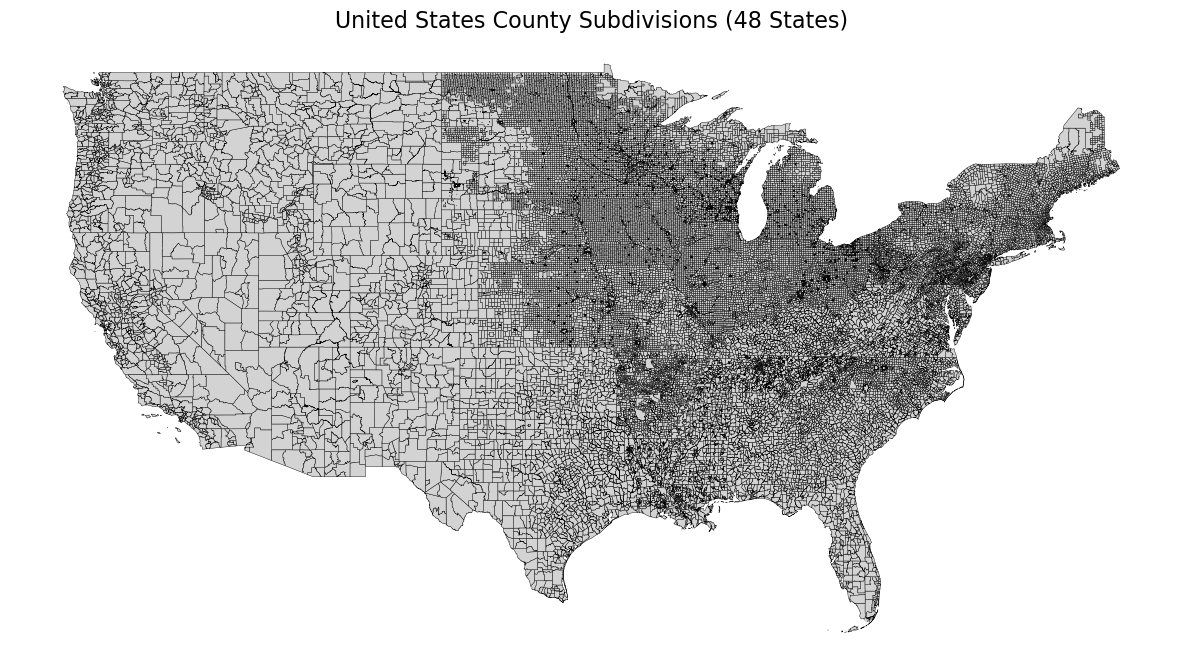

In [126]:
# Plot the map
fig, ax = plt.subplots(figsize=(15, 12))
gdf_contiguous.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.3)
ax.set_title('United States County Subdivisions (48 States)', fontsize=16)
plt.axis('off')
plt.savefig('VandanAmin_BaseMap.png')
plt.show()

## Get Ready for the Analysis

We will create some new columns:
- One for the area size of each subdivision.
- Group data by state when needed.

In [129]:
# Add a column for area in square kilometers
gdf_contiguous = gdf_contiguous.to_crs(epsg=3395)  # Project to meters
gdf_contiguous['Area_km2'] = gdf_contiguous['geometry'].area / 10**6  # convert m² to km²

# See what it looks like now
gdf_contiguous[['STUSPS', 'NAME', 'Area_km2']].head()


,STUSPS,NAME,Area_km2
0,MO,Elmwood,300.721609
1,ND,Latona,211.328102
2,ND,Cornell,200.286069
3,ND,Eldridge,197.635691
4,ND,Rolette,5.962627


## Insight 1: Number of Subdivisions per State

We count how many subdivisions each state has.

/var/folders/cx/9r73my4n79sgp6zlpz3y6hhh0000gn/T/ipykernel_73039/512920331.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=subdiv_count, x='STUSPS', y='SubdivisionCount', palette='Blues', ax=ax)


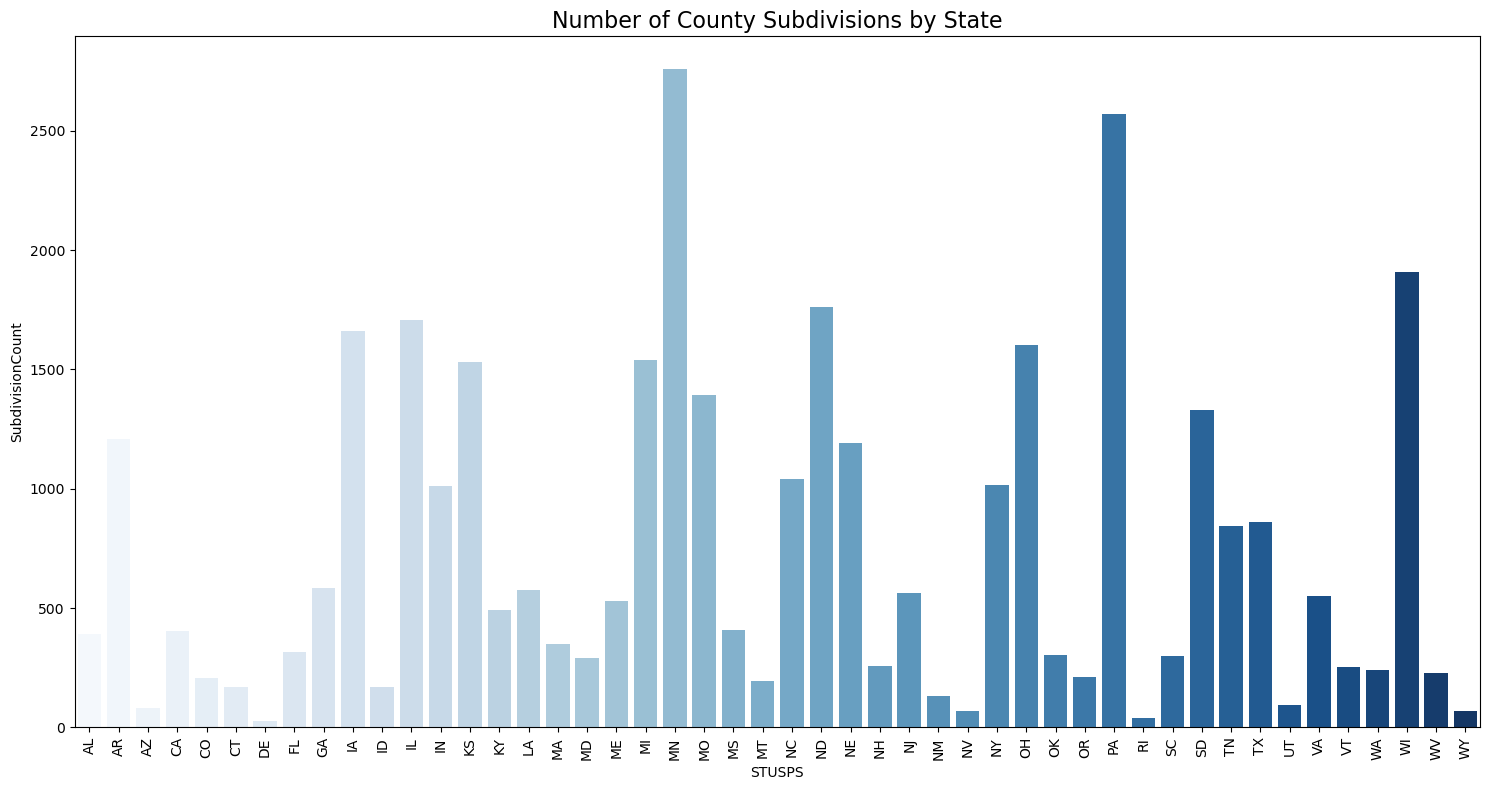

In [132]:
# Group by state and count subdivisions
subdiv_count = gdf_contiguous.groupby('STUSPS').size().reset_index(name='SubdivisionCount')

# Bar plot
fig, ax = plt.subplots(figsize=(15, 8))
sns.barplot(data=subdiv_count, x='STUSPS', y='SubdivisionCount', palette='Blues', ax=ax)
ax.set_title('Number of County Subdivisions by State', fontsize=16)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('VandanAmin_SubdivisionCount.png')
plt.show()


### Interpretation
States like Minnesota and Pennsylvania have the most county subdivisions.  
This usually happens because these states use a lot of small townships for local government.


## Insight 2: Average Area Size per State

We find the average land size of subdivisions in each state.

/var/folders/cx/9r73my4n79sgp6zlpz3y6hhh0000gn/T/ipykernel_73039/112319617.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_area, x='STUSPS', y='Area_km2', palette='Greens', ax=ax)


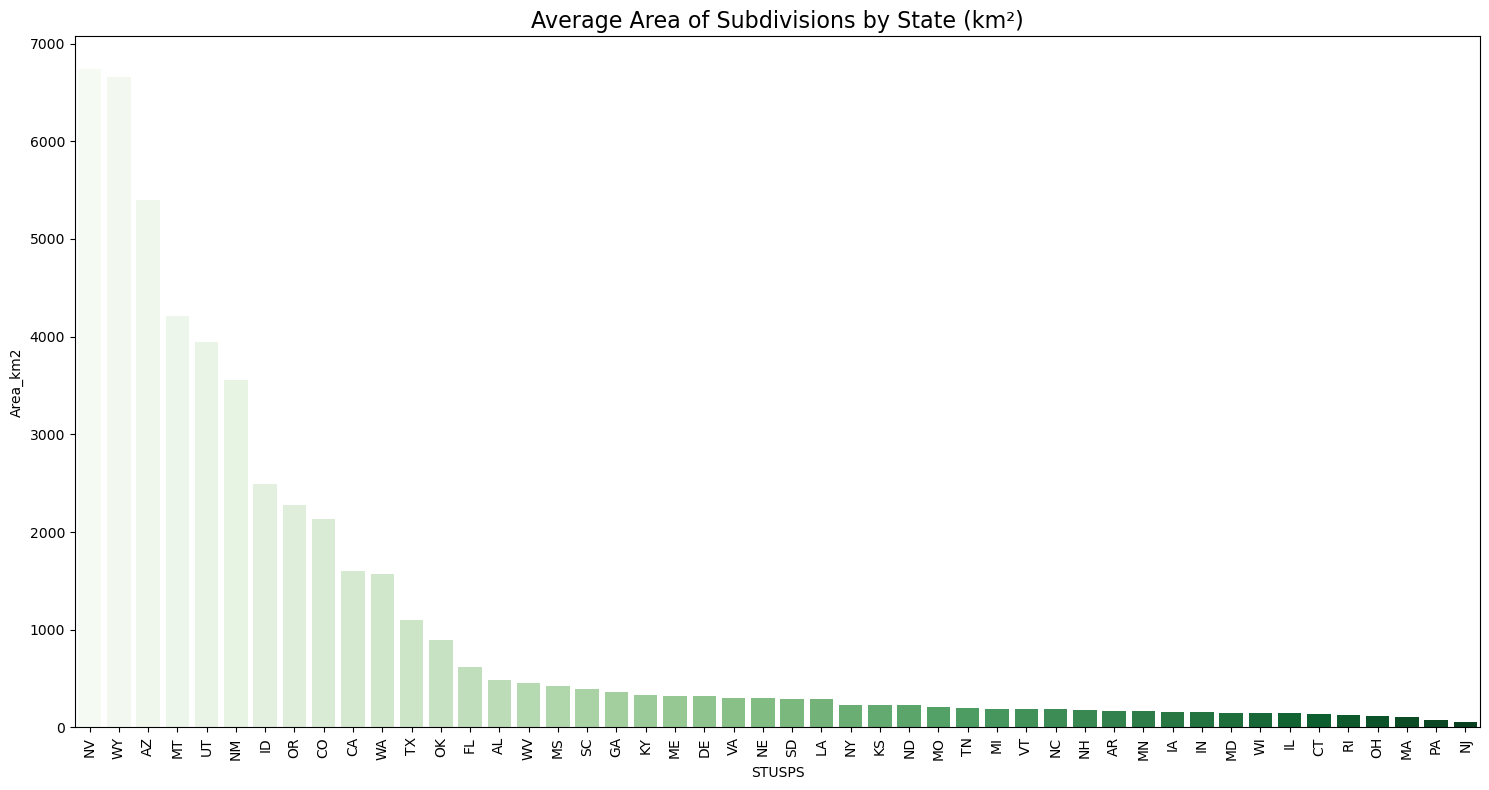

In [137]:
# Group by state and find average area
avg_area = gdf_contiguous.groupby('STUSPS')['Area_km2'].mean().reset_index()

# Sort biggest first
avg_area = avg_area.sort_values(by='Area_km2', ascending=False)

# Bar plot
fig, ax = plt.subplots(figsize=(15, 8))
sns.barplot(data=avg_area, x='STUSPS', y='Area_km2', palette='Greens', ax=ax)
ax.set_title('Average Area of Subdivisions by State (km²)', fontsize=16)
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('VandanAmin_AverageArea.png')
plt.show()

### Interpretation
Western states like Arizona and Montana have bigger subdivisions on average.  
This makes sense because the land is more open and rural there.

## Insight 3: Largest Subdivision in Each State

We find the biggest single subdivision in every state.


/var/folders/cx/9r73my4n79sgp6zlpz3y6hhh0000gn/T/ipykernel_73039/29706778.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_largest, x='Area_km2', y='STUSPS', palette='Oranges', ax=ax)


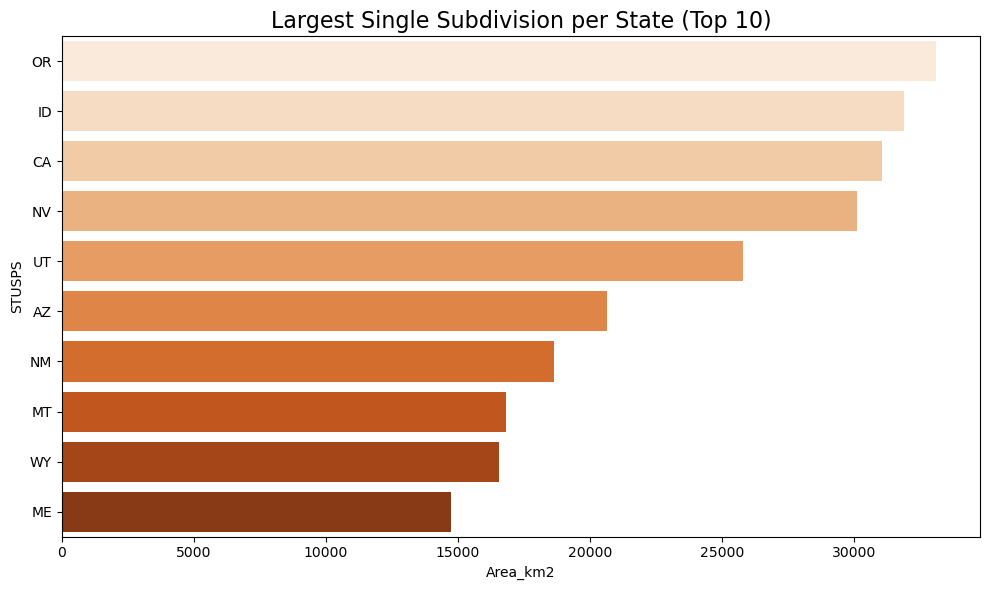

In [141]:
# Find the largest subdivision per state
largest_subdiv = gdf_contiguous.loc[gdf_contiguous.groupby('STUSPS')['Area_km2'].idxmax()]

# Plot the top 10 largest by area
top10_largest = largest_subdiv.nlargest(10, 'Area_km2')

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top10_largest, x='Area_km2', y='STUSPS', palette='Oranges', ax=ax)
ax.set_title('Largest Single Subdivision per State (Top 10)', fontsize=16)
plt.tight_layout()
plt.savefig('VandanAmin_LargestSubdivision.png')
plt.show()


### Interpretation
Most of the largest subdivisions are in western states. This is because western land was added later, allowing for bigger and more spread-out areas compared to the east. This shows how wide and spread-out some U.S. regions are.


## Insight 4: How Big Are Subdivisions?

We plot a histogram to see the spread of all subdivision areas.


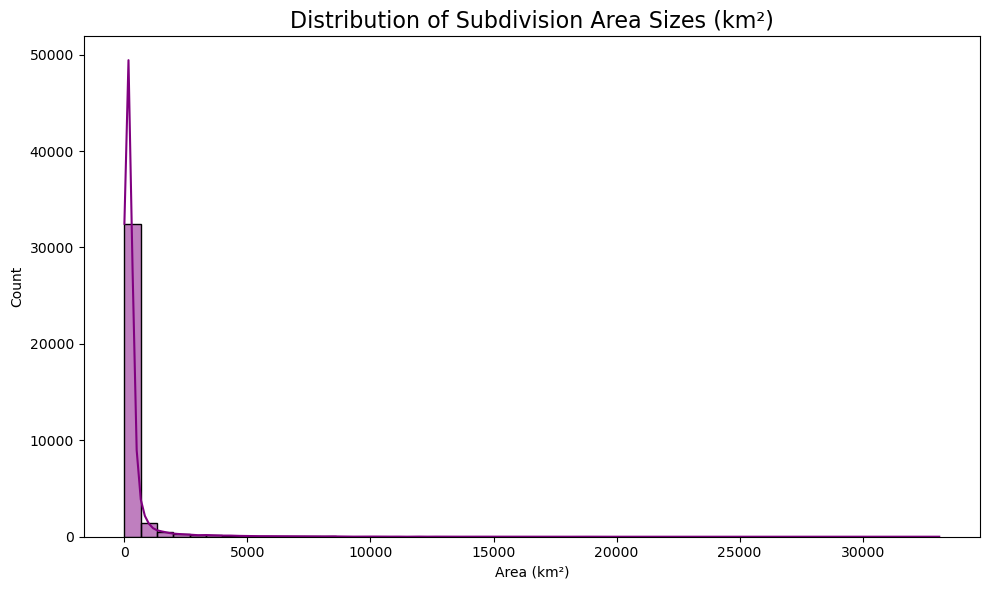

In [145]:
# Plot histogram
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(gdf_contiguous['Area_km2'], bins=50, kde=True, color='purple', ax=ax)
ax.set_title('Distribution of Subdivision Area Sizes (km²)', fontsize=16)
ax.set_xlabel('Area (km²)')
plt.tight_layout()
plt.savefig('VandanAmin_SubdivisionAreaHistogram.png')
plt.show()


### Interpretation
Most subdivisions are very small in area. Only a few subdivisions are extremely large, which creates a long tail in the distribution.

## Insight 5: Map by Number of Subdivisions

We color the states by how many county subdivisions they have.  
Darker colors mean more subdivisions.  
Lighter colors mean fewer subdivisions.

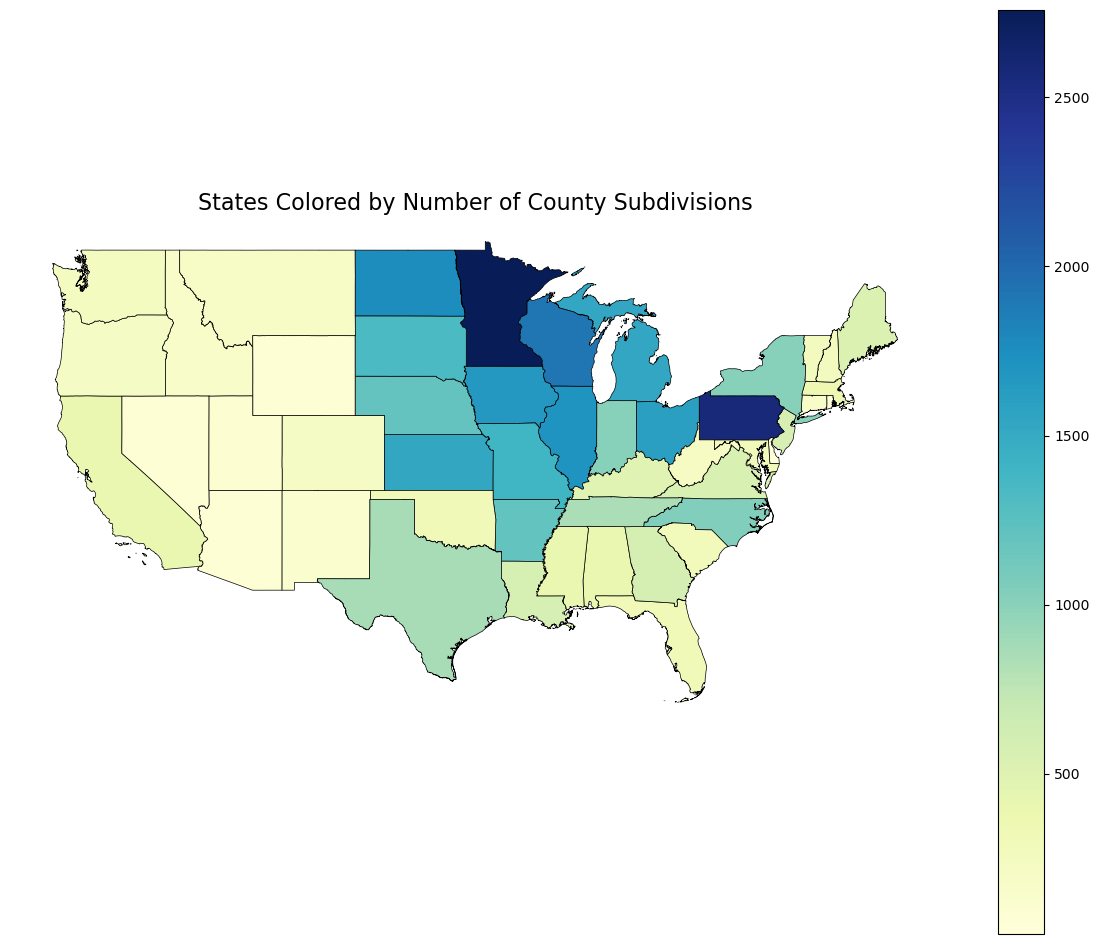

In [149]:
# Group by state and count subdivisions
subdiv_count = gdf_contiguous.groupby('STUSPS').size().reset_index(name='SubdivisionCount')
# Dissolve to get one shape per state
state_shapes = gdf_contiguous.dissolve(by='STUSPS', as_index=False)
# Merge subdivision count into the state_shapes
state_shapes = state_shapes.merge(subdiv_count, on='STUSPS')
# Plot the states colored by number of subdivisions
fig, ax = plt.subplots(figsize=(15, 12))
state_shapes.plot(column='SubdivisionCount', cmap='YlGnBu', linewidth=0.5, edgecolor='black', legend=True, ax=ax)
ax.set_title('States Colored by Number of County Subdivisions', fontsize=16)
plt.axis('off')
plt.savefig('VandanAmin_ChoroplethSubdivisionCount.png')
plt.show()

### Interpretation
Western states are colored lighter because their subdivisions are bigger.  
Eastern states are darker because they have many small towns and cities.


## Final Conclusion

In this lab, we explored and visualized the spatial distribution of county subdivisions across the 48 contiguous states of the United States.

We first created a clean base map showing the boundaries of all subdivisions.  
Then, we focused on the geographic distribution by overlaying real 2020 data.

Through our five visualizations, we uncovered different patterns:
- Some states, especially in the Midwest and Northeast, have many small subdivisions.
- Western states tend to have fewer and much larger subdivisions.
- A few subdivisions are extremely large, especially in rural areas.
- Most subdivisions are relatively small, but a few very large ones pull the average higher.
- The choropleth map made it easy to see how subdivision counts vary from state to state.

Overall, this lab showed how powerful maps and graphs can be in making geographic patterns easy to see and understand.  
Simple visual tools help turn raw spatial data into insights about how the country is organized.

